
Random_state:  95
       C-V1-E
44    40967.7
46  1412000.0
37   357575.7
27   131250.0
40   115151.0
59    13333.0
61    66666.6
62  1833333.3
44    1
46    0
37    0
27    0
40    1
59    0
61    1
62    1
Name: key, dtype: int64
              precision    recall  f1-score   support

     healing       0.00      0.00      0.00         4
 Not-healing       0.20      0.25      0.22         4

   micro avg       0.12      0.12      0.12         8
   macro avg       0.10      0.12      0.11         8
weighted avg       0.10      0.12      0.11         8
 samples avg       0.12      0.12      0.12         8



<Figure size 80000x24000 with 0 Axes>

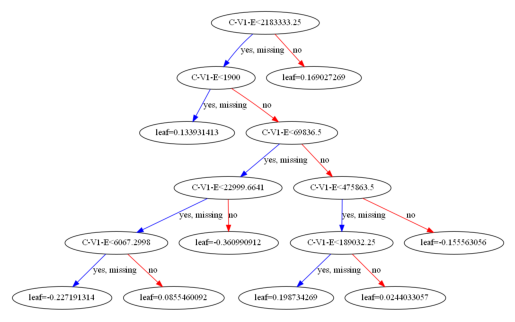

Accuracy: 12.5 %
------------------------------------------XGBClassifier 1-------------------------------
              precision    recall  f1-score   support

     healing       0.00      0.00      0.00         4
 Not-healing       0.43      0.75      0.55         4

   micro avg       0.38      0.38      0.38         8
   macro avg       0.21      0.38      0.27         8
weighted avg       0.21      0.38      0.27         8
 samples avg       0.38      0.38      0.38         8



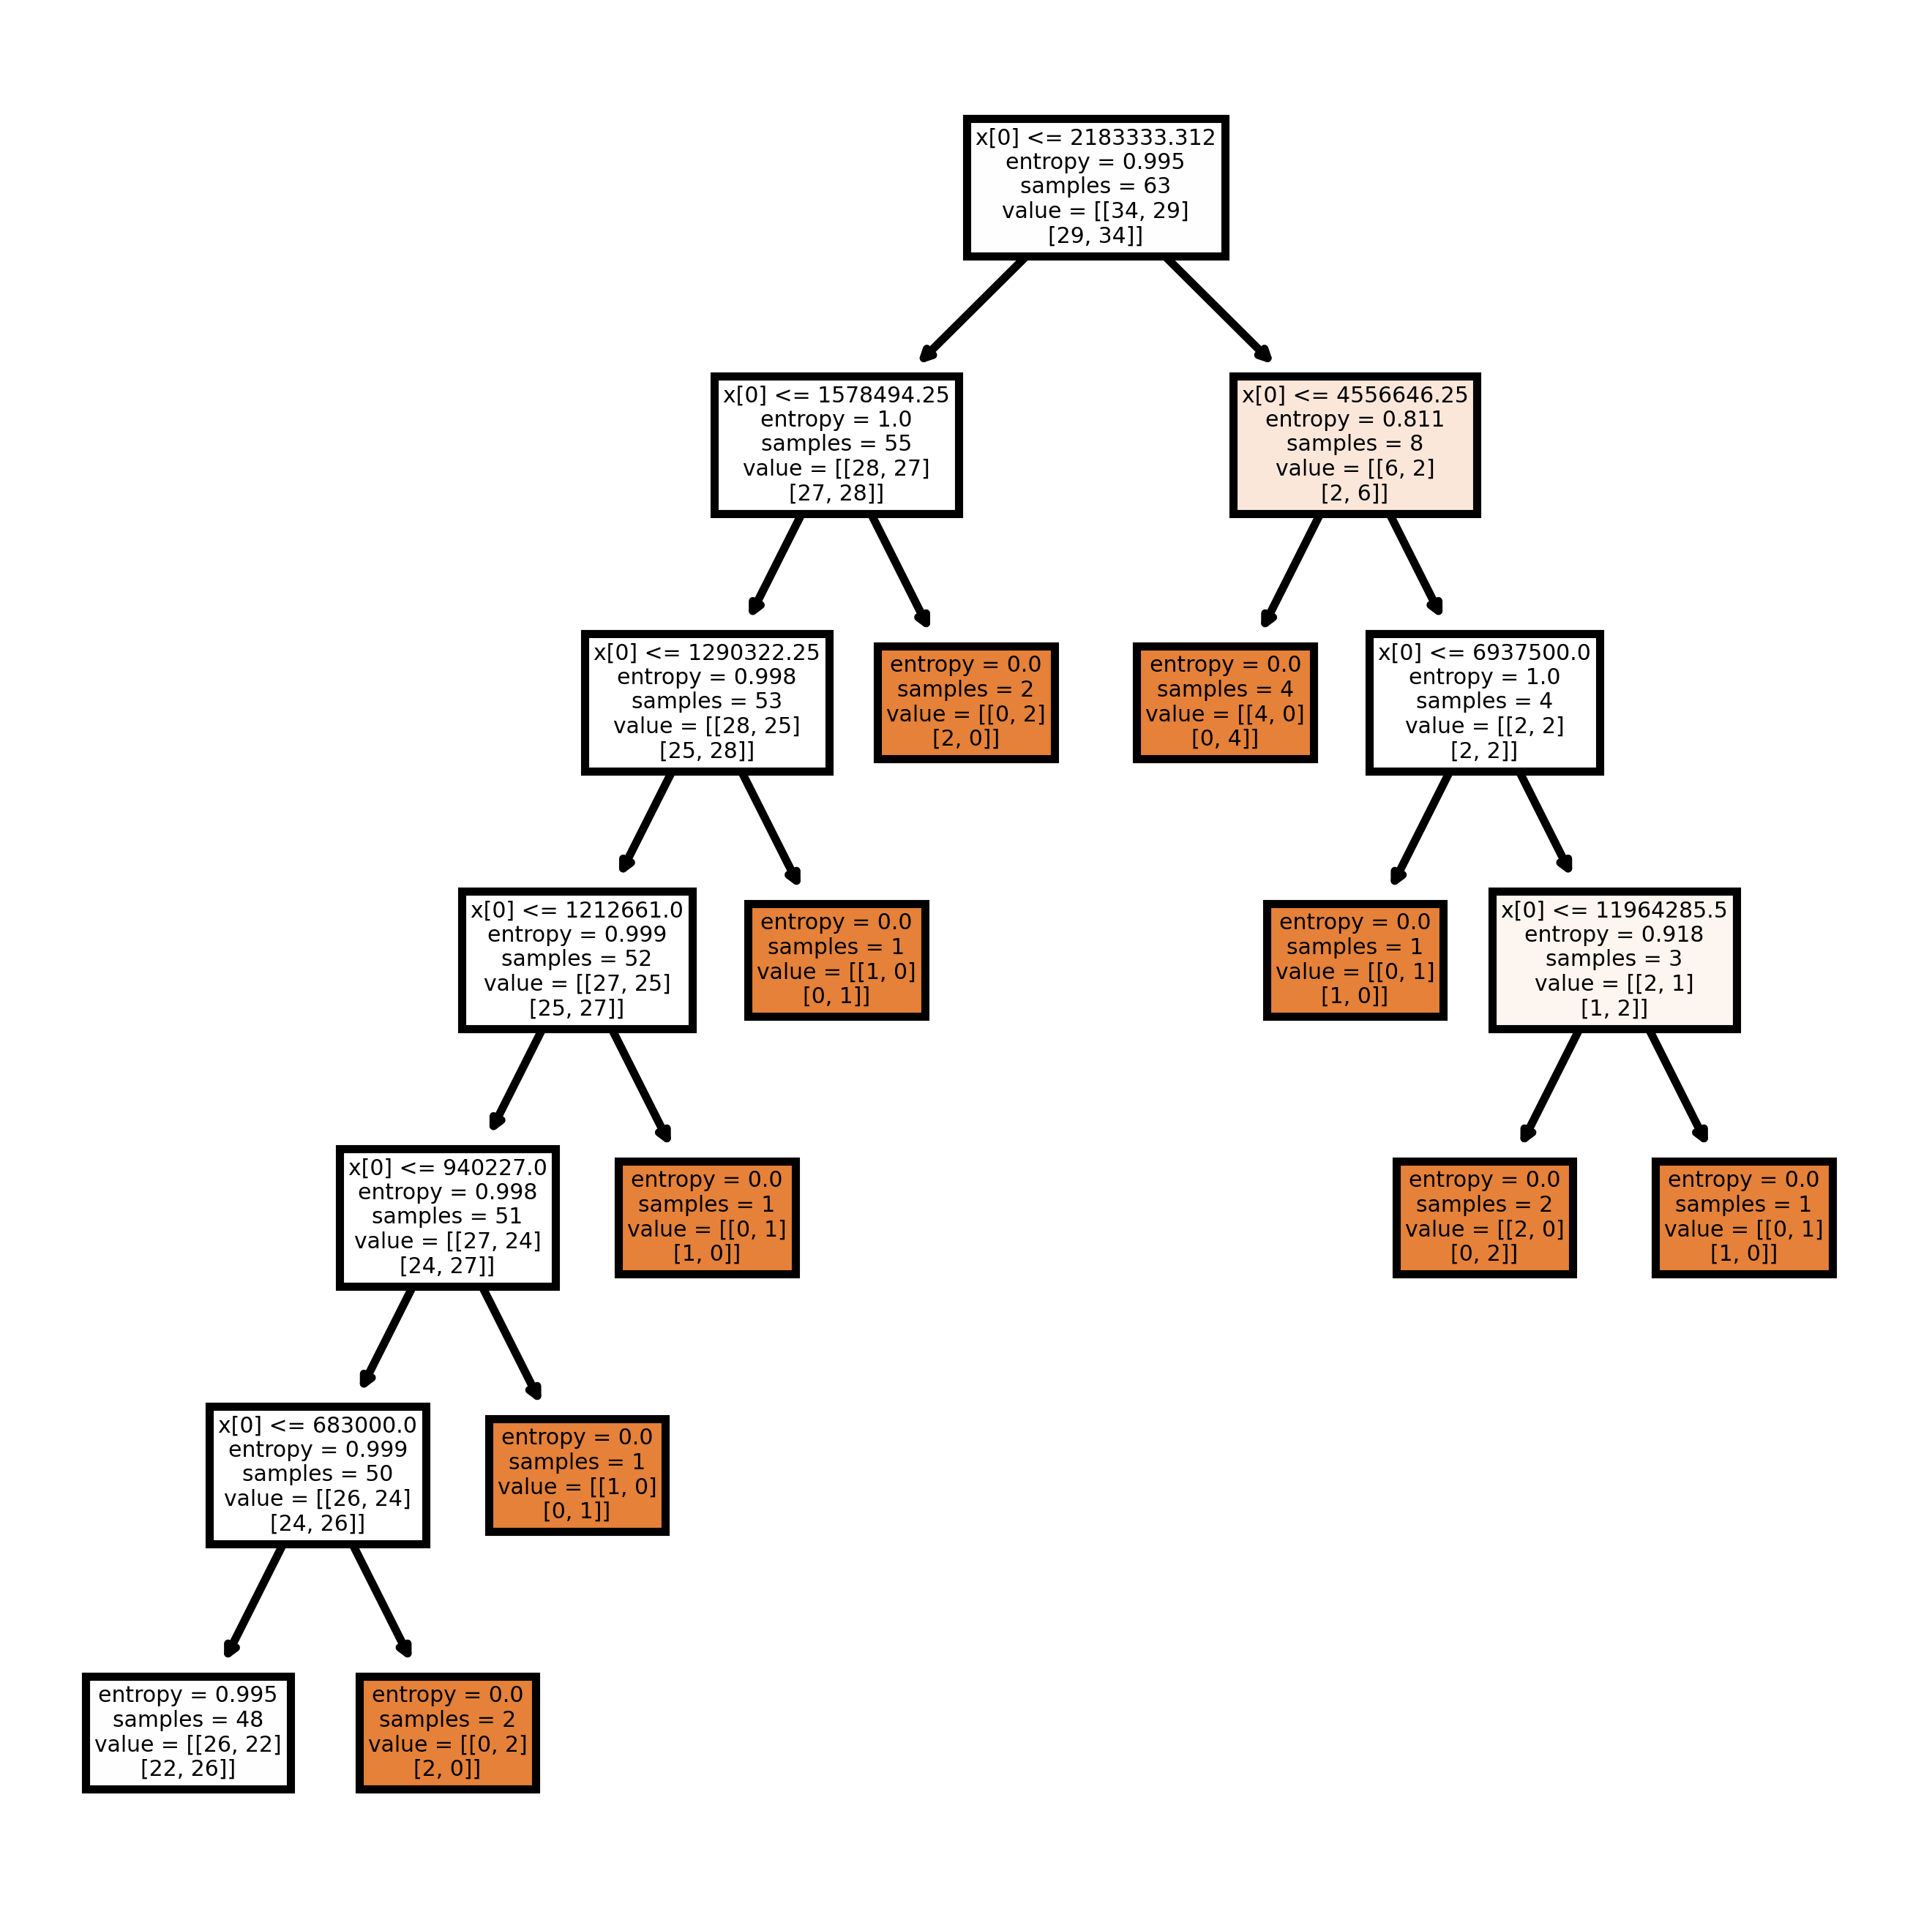

Accuracy: 37.5 %
------------------------------------------DecisionTreeClassifier 2-------------------------------


C:\Users\natej\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:777: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


              precision    recall  f1-score   support

     healing       0.00      0.00      0.00         4
 Not-healing       0.20      0.25      0.22         4

   micro avg       0.12      0.12      0.12         8
   macro avg       0.10      0.12      0.11         8
weighted avg       0.10      0.12      0.11         8
 samples avg       0.12      0.12      0.12         8



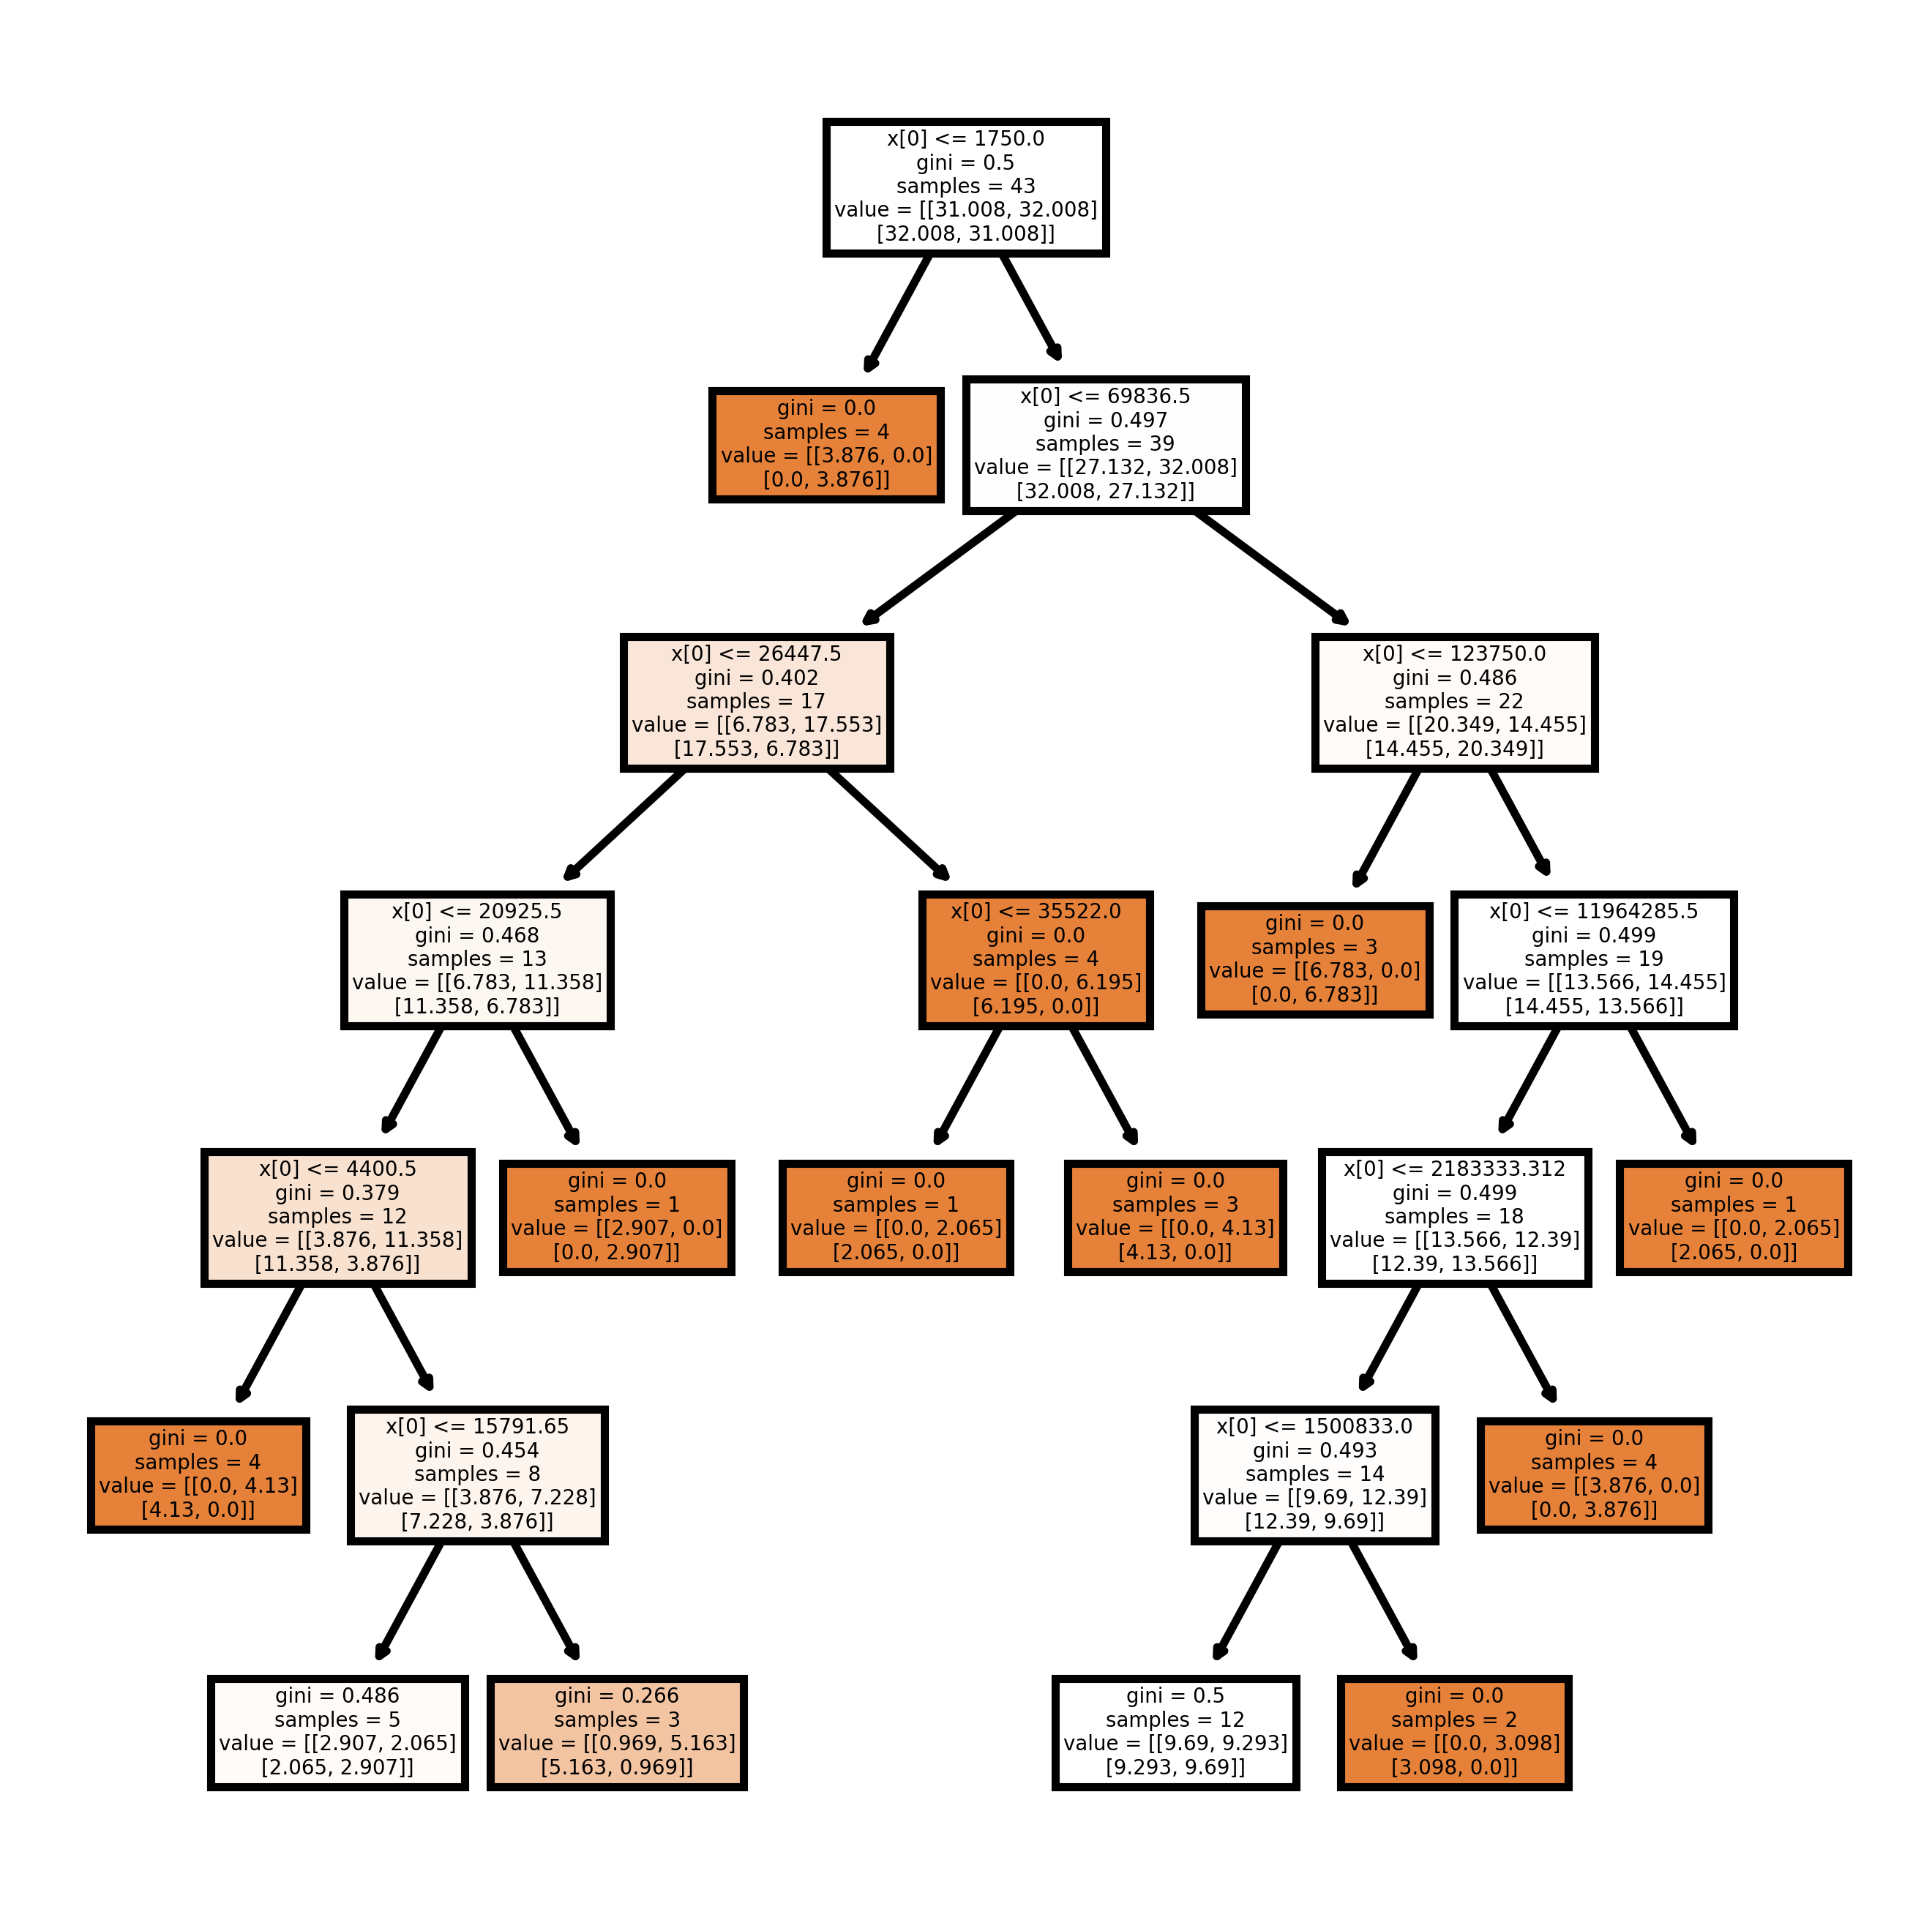

Accuracy: 12.5 %
------------------------------------------RandomForestClassifier 3-------------------------------


C:\Users\natej\anaconda3\Lib\site-packages\sklearn\ensemble\_forest.py:777: UserWarning: class_weight presets "balanced" or "balanced_subsample" are not recommended for warm_start if the fitted data differs from the full dataset. In order to use "balanced" weights, use compute_class_weight ("balanced", classes, y). In place of y you can use a large enough sample of the full training set target to properly estimate the class frequency distributions. Pass the resulting weights as the class_weight parameter.
  warn(


              precision    recall  f1-score   support

     healing       0.00      0.00      0.00         4
 Not-healing       0.20      0.25      0.22         4

    accuracy                           0.12         8
   macro avg       0.10      0.12      0.11         8
weighted avg       0.10      0.12      0.11         8

Accuracy: 12.5 %
''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''
Accuracy: 83.09859154929578 %
              precision    recall  f1-score   support

     healing       0.89      0.73      0.80        33
 Not-healing       0.80      0.92      0.85        38

    accuracy                           0.83        71
   macro avg       0.84      0.82      0.83        71
weighted avg       0.84      0.83      0.83        71

[[0.37441803 0.62558197]
 [0.30194277 0.69805723]
 [0.28239134 0.71760866]
 [0.24178804 0.75821196]
 [0.3944329  0.6055671 ]
 [0.33816091 0.66183909]
 [0.25776857 0.74223143]
 [0.33415745 0.66584255]
 [0.38

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import re
import matplotlib
import numpy as np
import pandas as pd
import xgboost as xgb
from xgboost import plot_tree
import graphviz
from xgboost import XGBRegressor
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import random
from tensorflow.keras.utils import to_categorical
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import pickle


Treatment=pd.read_csv("../dissertation/Cell 1+.csv")
df_x=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]
R_state=random.randrange(1,100)
print("Random_state: ",R_state)
R_state=29
X_train, X_test, y_train, y_test = train_test_split(df_x, df_y,test_size=0.1, random_state=R_state,stratify=df_y)
y_train_clf = to_categorical(y_train)
y_test_clf = to_categorical(y_test)
print(X_test)
print(y_test)
df_y=to_categorical(df_y)
fullinfo=True
fulltree=True
furtherinfo=False


def class1():
    clf=XGBClassifier(tree_method="exact",
                      
    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
        
        if fulltree==True:
            clf.fit(X_train, y_train)
            plt.figure(figsize=(800, 240))
            plot_tree(clf)
            #plt.savefig('DTC keras', dpi=1200)
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------XGBClassifier 1-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(np.asarray(df_y).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf

def class2():
    clf=DecisionTreeClassifier(max_depth=6,
                               
                              criterion="entropy",
                              
    )
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
            tree.plot_tree(clf, 
               filled = True);
            #f, axes = plt.subplots(1, 2, figsize=(15, 10))
            #axes = axes.ravel()
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------DecisionTreeClassifier 2-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(df_y, y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(df_y,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred.argmax(axis=1)),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf

def class3():
    clf = RandomForestClassifier(max_depth=6,warm_start=True,class_weight="balanced_subsample",n_estimators=500,random_state=9)
    if fullinfo==True:
        clf.fit(X_train, y_train_clf)
        y_pred = clf.predict(X_test)
        y_pred = (y_pred > 0.5) 
        print(classification_report(y_test_clf,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
        if fulltree==True:
            fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (4,4), dpi=800)
            tree.plot_tree(clf.estimators_[0], 
               filled = True);
            #f, axes = plt.subplots(1, 2, figsize=(15, 10))
            #axes = axes.ravel()
            plt.show()
        accuracy = accuracy_score(y_test_clf, y_pred)
        print("Accuracy:", (accuracy*100),"%")
        print("------------------------------------------RandomForestClassifier 3-------------------------------")
        if furtherinfo==True:
            print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
            y_pred = clf.predict(df_x)
           # accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
            accuracy = accuracy_score(df_y, y_pred)
            print("Accuracy:", (accuracy*100),"%")
            print(classification_report(df_y,y_pred,output_dict=False,target_names=["healing","Not-healing"]))
            f, axes = plt.subplots(1, 2, figsize=(15, 10))
            axes = axes.ravel()
            #goal_class=["Healing","non-healing","deterioration"]
            for i in range(2):
                disp = ConfusionMatrixDisplay(confusion_matrix(np.asarray(df_y).argmax(axis=1),
                                                       y_pred.argmax(axis=1)),
                                              display_labels=[0, i])
                disp.plot(ax=axes[i], values_format='.4g')
                #disp.ax_.set_title(goal_class[i])
                if i<10:
                    disp.ax_.set_xlabel('')
                if i%5!=0:
                    disp.ax_.set_ylabel('')
                disp.im_.colorbar.remove()

            plt.subplots_adjust(wspace=0.10, hspace=0.1)
            f.colorbar(disp.im_, ax=axes)
            plt.show()
            print("_______________________________________________________________________________________________")
    return clf
    

    
def VoteClass():
    clf1=class1()
    clf2=class2()
    clf3=class3()
    sclf = VotingClassifier(estimators=[('clf1', clf1), ('clf2', clf2), ('clf3', clf3)],voting='soft',flatten_transform=False)
    
    sclf.fit(X_train, y_train)
    
    y_pred = sclf.predict(X_test)
    print(classification_report(np.asarray(y_test_clf).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    
    accuracy = accuracy_score(np.asarray(y_test_clf).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    
    y_pred = sclf.predict_proba(X_test)
    print("''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''''")
    y_pred = sclf.predict(df_x)
    accuracy = accuracy_score(np.asarray(df_y).argmax(axis=1), y_pred)
    print("Accuracy:", (accuracy*100),"%")
    print(classification_report(np.asarray(df_y).argmax(axis=1),y_pred,output_dict=False,target_names=["healing","Not-healing"]))
    y_pred = sclf.predict_proba(df_x)
    print(y_pred)
    
    
    
#class3()
VoteClass()